### Hypothesis Testing

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# import microsoft.csv, and add a new feature - logreturn
ms = pd.read_csv('data/microsoft.csv')
ms['logreturn'] = np.log(ms['Close'].shift(-1)) - np.log(ms['Close'])

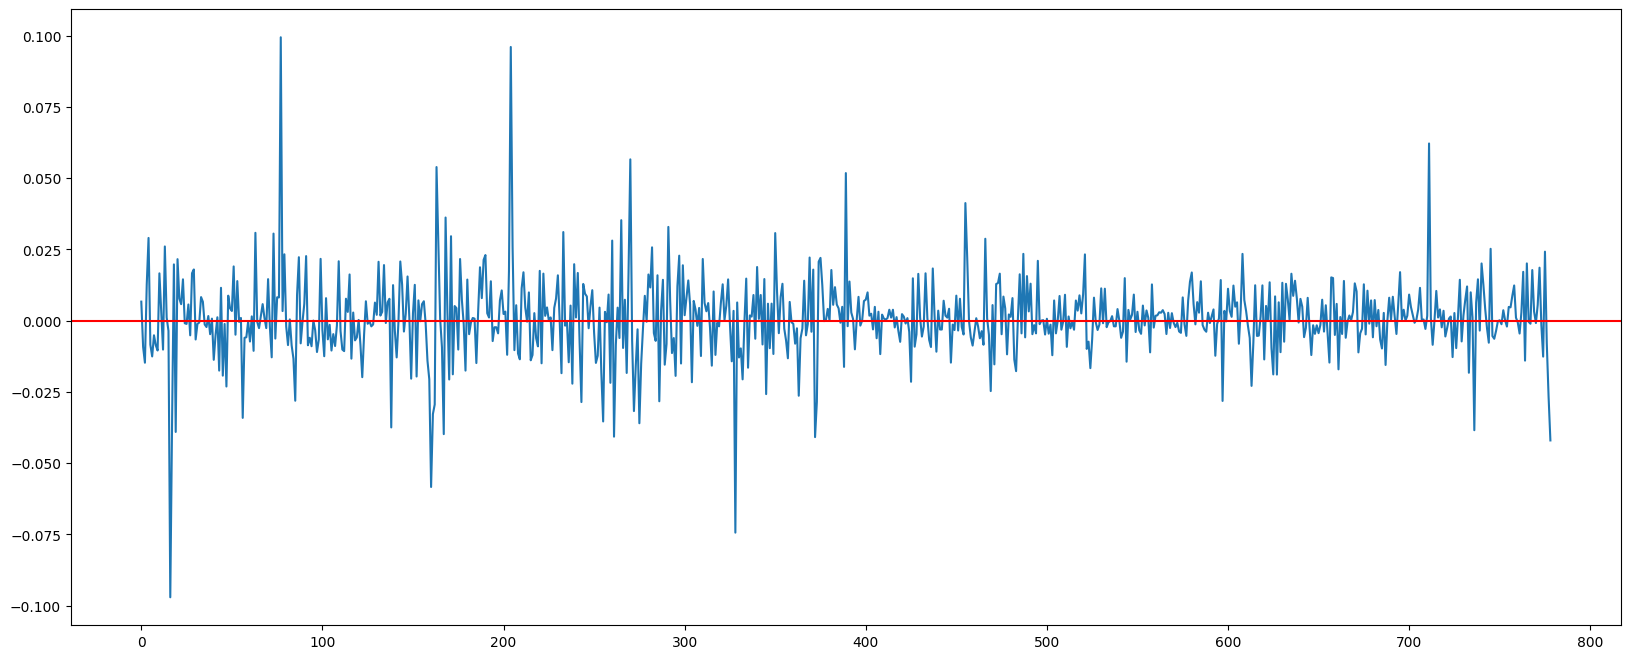

In [5]:
# Log return goes up and down during the period
ms['logreturn'].plot(figsize=(20,8))
plt.axhline(0,color='red')
plt.show()

### Steps involved in testing a claim by hypothesis testing

#### Step 1: Set Hypothesis

$$
H_0: \mu = 0
$$

$$
H_a: \mu \ne 0
$$

H0 means the average stock return is 0  
H1 means the average stock return is not equal to 0

#### Step 2: Calculate test statistic

In [6]:
sample_mean = ms['logreturn'].mean()
sample_std = ms['logreturn'].std(ddof=1)
n = ms['logreturn'].shape[0]

# if sample size n is large enough, we can use z-distribution, instead of t-distribution
# mu = 0 under the nul hypothesis
zhat = (sample_mean - 0)/(sample_std/n**0.5)
print(zhat)

1.614147714000367


#### Step 3: Set Decision Criteria

In [7]:
# confidence level
alpha = 0.05

zleft = norm.ppf(alpha/2,0,1)
zright = -zleft # z-distribution is symmetric
print(f'zleft: {zleft}, zright: {zright}')

zleft: -1.9599639845400545, zright: 1.9599639845400545


#### Step 4: Make decision - shall we reject H0 ?

In [8]:
print('At significant level of {}, shall we reject: {}'.format(alpha, zhat>zright or zhat<zleft))

At significant level of 0.05, shall we reject: False


### One Tail Test

$$
H_0: \mu  \leq  0
$$

$$
H_a: \mu > 0
$$


In [10]:
# step 2
sample_mean = ms['logreturn'].mean()
sample_std = ms['logreturn'].std(ddof=1)
n = ms['logreturn'].shape[0]

# if sample size n is large enough, we can use z-distribution, instead of t-distribution
# mu=0 under the null hypothesis
zhat = (sample_mean - 0)/(sample_std/n**0.5)
print(zhat)

1.614147714000367


In [11]:
# Step 3
alpha = 0.05

zright = norm.ppf(1-alpha,0,1)
print(zright)

1.6448536269514722


In [12]:
# Step 4
print('At significant level of {}, shall we reject: {}'.format(alpha, zhat>zright))

At significant level of 0.05, shall we reject: False


### An alternative method: p-value

In [13]:
# Step 3 (p-value)
p = 1 - norm.cdf(zhat,0,1)
print(p)

0.053247694996968464


In [14]:
# Step 4
print('At significant level of {}, shall we reject: {}'.format(alpha, p < alpha))

At significant level of 0.05, shall we reject: False
